In [1]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
import plotly.graph_objects as go

In [2]:
#Given Values
p_max = 124.4e3 #Pa
p_min = 86.7e3 #Pa
delta_p = p_max - p_min #Pa
T = 10 #s

omega = 2 * np.pi / T  # angular frequency (rad/s)

#Assumed values
g = 9.81 #m/s^2
rho = 1025 #kg/m^3, from EngineeringToolbox


# Create the empty DataFrame
df = pd.DataFrame(columns=
                 [
    'water_depth', # d
    'wave_height', # H
    'wavelength', # L
    'celerity', # C
    'theta', # for plotting
    'wave_profile', # η
    'seafloor_pressure', # p at z = -d
    'z_cr', # for plotting
    'z_tr',
    'crest_pressure', # p(θ = 0)
    'trough_pressure', # p(θ = π)
    'crest_u', #u(θ = 0)
    'trough_u' #u(θ = π)
])


# Linear

In [3]:
#Calculating h
d_lin = .5 * (p_max + p_min) / (rho*g)
d_lin

10.497004052609334

In [4]:
#Set up the dispersion relation
def dispersion_relation(k, d):
    return omega**2 - g * k * np.tanh(k * d)

In [5]:
#Set an initial guess for k
k_initial_guess = 0.05  # rad/m
#Solve the dispersion relation iteratively using Newton-Raphson Method
k_solution = fsolve(dispersion_relation, k_initial_guess, args=(d_lin))[0]

In [6]:
#Calculate L using k
L_lin = 2 * np.pi / k_solution  #m

#Calculate H
H_lin = (delta_p * (np.cosh(k_solution * d_lin))) / (rho * g)  #m

In [7]:
#Define linear hydrodynamic pressure function
def pres_lin(z, theta, H, k, d):
    #calculates hydrodynamic pressure
    return (rho * g * H / 2.0) * (np.cosh(k * (z + d)) / np.cosh(k * d)) * np.cos(theta)

#Define linear horizontal velocity function
def lin_u(z, theta, H, k, d):
    omega = 2 * np.pi / T
    return (omega * H / 2.0) * (np.cosh(k * (z + d)) / np.sinh(k * d)) * np.cos(theta)

In [8]:
'''
Calculating all of the variables for linear plots
'''
#linear wave profile, theta, and z
theta = np.linspace(0, 2*np.pi, 100)
lin_wp = (H_lin/2) * np.cos(theta)
z_cr = np.linspace(-d_lin, max(lin_wp), 100)
z_tr = np.linspace(-d_lin, min(lin_wp), 100)

#linear dynamic pressure
p_lin_sf = pres_lin(-d_lin, theta, H_lin, k_solution, d_lin)

#linear pressure under trough
p_lin_tr = pres_lin(z_tr, np.pi, H_lin, k_solution, d_lin)
#linear pressure under crest
p_lin_cr = pres_lin(z_cr, 0, H_lin, k_solution, d_lin)

#linear horizontal veloicty under trough
lin_u_tr = lin_u(z_tr, np.pi, H_lin, k_solution, d_lin)
#linear horizontal veloicty under crest
lin_u_cr = lin_u(z_cr, 0, H_lin, k_solution, d_lin)

In [9]:
C_lin = 9.43 #m/s, pulled from ACES

#Add all linear data to the dataframe
df.loc['Linear'] = [
    d_lin,
    H_lin,
    L_lin,
    C_lin,
    theta,
    lin_wp,
    p_lin_sf,
    z_cr,
    z_tr,
    p_lin_tr,
    p_lin_cr,
    lin_u_tr,
    -lin_u_cr
]

In [10]:
#Define equation for 2nd order Stokes
def pres_stokes(z, theta, H, k, d):
    s = z + d 
    L = (2*np.pi) / k
    sinh_kd = np.sinh(k * d)
    cosh_ks = np.cosh(k * s)
    cosh_2ks = np.cosh(2 * k * s)
    sinh_2kd = np.sinh(2 * k * d)
    sinh2_kd = sinh_kd ** 2

    #Break equation into terms for easier calculation
    term1 = 0.5 * rho * g * H * (cosh_ks / np.cosh(k * d)) * np.cos(theta)

    term2_coeff = (3/4) * rho * g * H * (np.pi * H / L) * (1 / sinh_2kd)
    term2_bracket = (cosh_2ks / sinh2_kd) - (1/3)
    term2 = term2_coeff * term2_bracket * np.cos(2 * theta)

    term3_coeff = (1/4) * rho * g * H * (np.pi * H / L) * (1 / sinh_2kd)
    term3 = term3_coeff * (cosh_2ks - 1)

    p_hydro = term1 + term2 - term3
    return p_hydro

#Equation that adds static pressure to value found from above function
def total_pres_stokes(z, theta, H, k, d):
    p_dynamic = pres_stokes(z, theta, H, k, d)
    p_hydrostatic = rho * g * (-z)
    p_total = p_dynamic + p_hydrostatic
    return p_total

#Function that calculats horizontal velocity. 
def stokes_u(z, theta, H, k, d):
    s = z + d
    sinh_kd = np.sinh(k * d)
    sinh_kd_4 = sinh_kd ** 4
    
    term1 = (np.cosh(k * s) / sinh_kd) * np.cos(theta)
    term2 = (3/4) * (H * k) * (np.cosh(2 * k * s) / sinh_kd_4) * np.cos(2 * theta)
    
    u = (np.pi * H / T) * (term1 + term2)*2
    
    return u

#function that calculates eta
def stokes_eta(d, theta, H, k):
    L = (2 * np.pi) / k
    kd = k * d

    depth_correction = np.cosh(kd) / (np.sinh(kd) ** 3)

    eta = (H / 2) * np.cos(theta) + (H / 8) * (np.pi * H / L) * depth_correction * (2+np.cosh(2*k*d)) * np.cos(2 * theta)

    return eta


In [11]:
# Iterative solver for H and d

def stokes_iterative_solver(target_pressure_high, target_pressure_low, max_iter=100, tol=1e-3):
    #d = d_lin  # start with linear d & H as guess for iterative solver
    #H = H_lin
    '''
    after trial and error these values were found to be good starting points
    '''
    d = 9.23
    H = 5.4
    
    #Put in a limit on the number of iterations
    for i in range(max_iter):
        #use some guess for k
        k_initial_guess = omega**2 / g
        #iteratively solve dispersion relation
        k = fsolve(dispersion_relation, k_initial_guess, args=(d,))[0]
        #calculate corresponding pressures
        p_crest = total_pres_stokes(-d, 0, H, k, d)
        p_trough = total_pres_stokes(-d, np.pi, H, k, d)
        #find the error between calculated and measured pressures
        error_high = (p_crest - target_pressure_high) / (target_pressure_high)
        error_low = (p_trough - target_pressure_low) / (target_pressure_low)
        #find MSE
        #error = (error_high + error_low)/2
        error = (abs(error_high) + abs(error_low))/2
        #use absolute MSE for printing to see if the errors are cancelling out
        error_print = (abs(error_high) + abs(error_low))/2
        #print values every 20 iterations
        if i % 20 == 0 or abs(error) < tol:
            print(f"Iter {i}: d = {d:.3f}, H = {H:.3f}, k = {k:.3f}, p = {p_crest:.2f}, error = {error_print*100:.2f} %")

        #if below the tolerance value, end
        if abs(error) < tol:
            break
        #Otherwise increase/decrease H & d
        '''
        these change values were also found via trial and error
        '''
        if error > 0:
            H -= 0.001
            #d -= 0.00001
        else:
            H += 0.001
            #d += 0.00001

    return H, d, k

In [12]:
# Iterative solver for H and d

def stokes_iterative_solver(target_pressure_high, target_pressure_low, max_iter=100, tol=1e-3):
    #d = d_lin  # start with linear d & H as guess for iterative solver
    #H = H_lin
    '''
    after trial and error these values were found to be good starting points
    '''
    d = 10.1
    H = 4.84

    #Loop through values up to number of max iterations
    for i in range(max_iter):

        #solve for k
        k_initial_guess = omega**2 / g
        k = fsolve(dispersion_relation, k_initial_guess, args=(d,))[0]

        #Calculate corresponding pressure values
        p_crest = total_pres_stokes(-d, 0, H, k, d)
        p_trough = total_pres_stokes(-d, np.pi, H, k, d)
    
        #Find error by defining a vector from calcualted to actual values, using that to update the guessed values
        #This is a somewhat complicated error method, but was the best I found that allows you to take in two errors and output 
            #two modifiers, all of which are sign dependent.
        
        error_vec = np.array([(p_crest - target_pressure_high)/target_pressure_high, (p_trough - target_pressure_low)/target_pressure_low])
        
        # Update H and d
        H -= .0001 * error_vec[0] 
        d -= .00001 * error_vec[1]
        
        #Find the normal error
        error_norm = np.linalg.norm(error_vec)
        
        # Print progress 10000 iterations
        if i % 10000 == 0 or error_norm < tol:
            print(f"Iter {i}: d = {d:.5f}, H = {H:.5f}, k = {k:.5f}, "f"p_crest = {p_crest:.2f}, p_trough = {p_trough:.2f}, "f"error_norm = {error_norm:.5f}")
        
        if error_norm < tol:
            break

    return H, d, k, p_crest, p_trough, error_norm

In [13]:
# Run the solver
H_stokes, d_stokes, k_stokes, p_cr_stokes, p_tr_stokes, error_stokes = stokes_iterative_solver(p_max, p_min, max_iter = 100000, tol = 1e-4)

Iter 0: d = 10.10000, H = 4.84000, k = 0.06773, p_crest = 126014.16, p_trough = 86868.83, error_norm = 0.01312
Iter 10000: d = 10.09979, H = 4.82734, k = 0.06773, p_crest = 125935.75, p_trough = 86892.61, error_norm = 0.01254
Iter 20000: d = 10.09956, H = 4.81530, k = 0.06773, p_crest = 125860.92, p_trough = 86914.96, error_norm = 0.01200
Iter 30000: d = 10.09930, H = 4.80384, k = 0.06773, p_crest = 125789.49, p_trough = 86935.94, error_norm = 0.01150
Iter 40000: d = 10.09901, H = 4.79295, k = 0.06773, p_crest = 125721.31, p_trough = 86955.61, error_norm = 0.01102
Iter 50000: d = 10.09871, H = 4.78259, k = 0.06773, p_crest = 125656.22, p_trough = 86974.03, error_norm = 0.01058
Iter 60000: d = 10.09838, H = 4.77275, k = 0.06774, p_crest = 125594.10, p_trough = 86991.26, error_norm = 0.01017
Iter 70000: d = 10.09804, H = 4.76339, k = 0.06774, p_crest = 125534.79, p_trough = 87007.34, error_norm = 0.00979
Iter 80000: d = 10.09767, H = 4.75450, k = 0.06774, p_crest = 125478.18, p_trough = 

In [14]:
print(f"\nFinal results for Stokes:"
      f"\nWave Height H = {H_stokes:.3f} m"
      f"\nWater Depth d = {d_stokes:.3f} m"
      f"\nWavenumber k = {k_stokes:.3f} rad/m"
      f"\nCrest Pressure = {p_cr_stokes:.3f} Pa"
      f"\nTrough Pressure = {p_tr_stokes:.3f} Pa"
      f"\nFinal Solver Error = {error_stokes*100:.3f}%")


Final results for Stokes:
Wave Height H = 4.738 m
Water Depth d = 10.097 m
Wavenumber k = 0.068 rad/m
Crest Pressure = 125372.553 Pa
Trough Pressure = 87049.242 Pa
Final Solver Error = 0.879%


In [15]:
c_stokes = np.sqrt((omega**2) / (k_stokes**2)) #m/s
L_stokes = (2*np.pi) / k_stokes

In [16]:
'''
calculate all of the values for Stokes Plots
'''


#stokes hydrodynamic pressure
p_stokes_sf = pres_stokes(-d_stokes, theta, H_stokes, k_stokes, d_stokes)
#stokes wave profile
stokes_wp = stokes_eta(d_stokes, theta, H_stokes, k_stokes)

z_cr_s = np.linspace(-d_stokes, stokes_wp.max(), 100)
z_tr_s = np.linspace(-d_stokes, stokes_wp.min(), 100)

#Stokes pressure under trough
p_stokes_tr = pres_stokes(z_tr_s, np.pi, H_stokes, k_stokes, d_stokes)
#Stokes pressure under crest
p_stokes_cr = pres_stokes(z_cr_s, 0, H_stokes, k_stokes, d_stokes)

#stokes u under trough
stokes_u_tr = stokes_u(z_tr_s, np.pi, H_stokes, k_stokes, d_stokes)
#stokes u under crest
stokes_u_cr = stokes_u(z_cr_s, 0, H_stokes, k_stokes, d_stokes)



In [17]:
# Add row to DataFrame
df.loc['Stokes'] = [
    d_stokes,
    H_stokes,
    L_stokes,
    c_stokes,
    theta,
    stokes_wp,
    p_stokes_sf,
    z_cr_s,
    z_tr_s,
    p_stokes_cr,
    p_stokes_tr,
    stokes_u_tr,
    stokes_u_cr
]


# Cnoidal

In [18]:
H_c = 6.1 #m
d_c = 10.15 #m
L_c = 97.68 #m
c_c = 9.77 #m/s

#All of the data extracted for Cnoidal from ACES
xL = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
eta_c_raw = np.array([4.45, 2.03, -0.48, -1.35, -1.6, -1.65, -1.6, -1.35, -0.48, 2.03, 4.45])
c_pres_raw = np.array([124523, 121461, 106639, 93614, 88133, 86827, 88133, 93614, 106639, 121461, 124523])

depth_crest_c_raw = np.array([4.45, 2.99, 1.53, 0.07, -1.39, -2.85, -4.31, -5.77, -7.23, -8.69, -10.15])
p_under_crest_c_raw = np.array([8049, 19622, 30467, 40936, 51339, 61945, 72981, 84633, 97045, 110321, 124523])
u_under_crest_c_raw = np.array([7.57, 6.47, 5.48, 4.61, 3.86, 3.22, 2.7, 2.3, 2.01, 1.83, 1.77])

depth_trough_c_raw = np.array([-1.65, -2.5, -3.35, -4.2, -5.05, -5.9, -6.75, -7.6, -8.45, -9.3, -10.15])
p_under_trough_c_raw = np.array([554, 9257, 17943, 26612, 35264, 43900, 52518, 61120, 69706, 78275, 86827])
u_under_trough_c_raw = np.array([-2.03, -2.01, -2.0, -1.99, -1.98, -1.97, -1.97, -1.96, -1.96, -1.96, -1.96])


In [19]:
#function that converts from total to hydrodynamic pressure
def hydrodynamic(p_total, z):
    #convert z to water column height
    p_dy = p_total + (rho*g*z)
    return p_dy

p_under_crest_c = hydrodynamic(p_under_crest_c_raw, depth_crest_c_raw)
p_under_trough_c = hydrodynamic(p_under_trough_c_raw, depth_trough_c_raw)

In [20]:
# Add row to DataFrame
df.loc['Cnoidal'] = [
    d_c,
    H_c,
    L_c,
    c_c,
    xL * 2* np.pi, #convert x/L to radians
    eta_c_raw,
    c_pres_raw - (rho*g*d_c), #convert to hydrodynamic
    depth_crest_c_raw,
    depth_trough_c_raw,
    p_under_crest_c,
    p_under_trough_c,
    u_under_crest_c_raw,
    u_under_trough_c_raw
]

# Fourier

In [21]:
H_f = 6.2 #m
d_f = 9.95 #m
L_f = 100.13 #m
c_f = 10.031 #m/s

#All of the data extracted for Fourier from ACES
xL_f = np.array([0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1])
eta_f_raw = np.array([4.767, 3.238, 1.458, -0.487, -1.163, -1.368, -1.413, -1.368, -1.163, -0.487, 1.458, 3.238, 4.787])
f_pres_raw = np.array([124369, 122109, 116058, 100617, 90867, 87170, 86319, 87170, 90867, 100617, 116058, 122109, 124369])

depth_crest_f_raw = np.array([4.78, 3.31, 1.84, 0.37, -1.1, -2.57, -4.04, -5.51, -6.98, -8.45, -9.95])
p_under_crest_f_raw = np.array([48, 10124, 20592, 31585, 43266, 55526, 68322, 81606, 95342, 109501, 124369])
u_under_crest_f_raw = np.array([6.1, 5.05, 4.26, 3.67, 3.209, 2.858, 2.593, 2.4, 2.27, 2.19, 2.164])

depth_trough_f_raw = np.array([-1.41, -2.26, -3.11, -3.96, -4.81, -5.66, -6.51, -7.36, -8.21, -9.06, -9.95])
p_under_trough_f_raw = np.array([1.59, 8604, 17321, 25849, 34460, 43062, 51654, 60236, 68807, 77368, 86319])
u_under_trough_f_raw = np.array([-1.69, -1.68, -1.67, -1.664, -1.659, -1.654, -1.65, -1.647, -1.644, -1.643, -1.642])


In [22]:
#Convert to Hydrodynamic
p_under_crest_f = hydrodynamic(p_under_crest_f_raw, depth_crest_f_raw)
p_under_trough_f = hydrodynamic(p_under_trough_f_raw, depth_trough_f_raw)

In [23]:
df.loc['Fourier'] = [
    d_f,
    H_f,
    L_f,
    c_f,
    xL_f * 2 * np.pi, #Convert to radians
    eta_f_raw,
    f_pres_raw - (rho*g*d_f), #convert to hydrodynamic
    depth_crest_f_raw,
    depth_trough_f_raw,
    p_under_crest_f,
    p_under_trough_f,
    u_under_crest_f_raw,
    u_under_trough_f_raw
]

In [24]:
#Round all the values
er_s_rounded = round(error_stokes,2)
df['Normalized Error (%)'] = ['-', '0.78%', '0.18%', '0.22%']
p_cr_stokes, p_tr_stokes

(np.float64(125372.55305398483), np.float64(87049.24247279234))

# Generating Outputs for Report

In [25]:
#Create a table for Question 1
final_table = df[['water_depth', 'wave_height', 'wavelength', 'celerity', 'Normalized Error (%)']].rename(columns={
    'water_depth': 'Water Depth (m)',
    'wave_height': 'Wave Height (m)',
    'wavelength': 'Wavelength (m)',
    'celerity': 'Celerity (m/s)',
    'Normalized Error (%)': 'Normalized Pressure Error (%)'
})
final_table=final_table.round(2)
#final_table

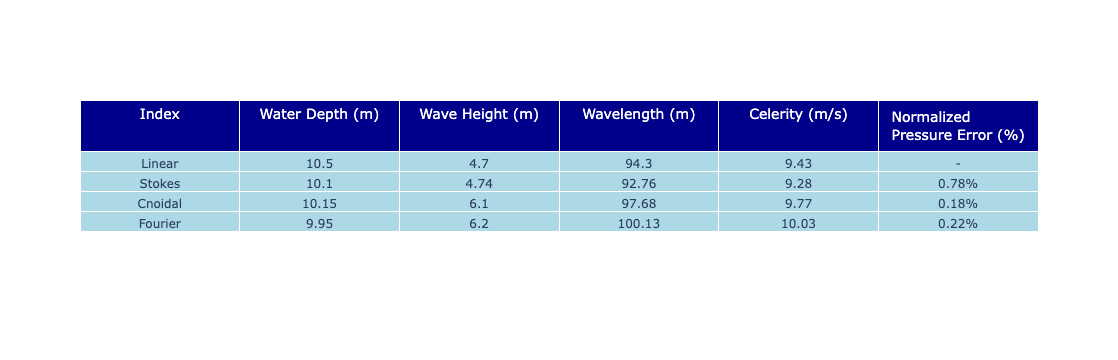

In [26]:
# Add the index as a separate column (for display only)
fig = go.Figure(data=[go.Table(
    header=dict(
        values=['Index'] + list(final_table.columns),  # prepend 'Index'
        fill_color='darkblue',
        font_color='white',
        font_size=14,
        align='center'
    ),
    cells=dict(
        values=[final_table.index] + [final_table[col] for col in final_table.columns],  # prepend index values
        fill_color='lightblue',
        font_size=12,
        align='center'
    )
)])

fig.show()

# Save as PDF
#fig.write_image("Final_Table_Plotly.pdf")

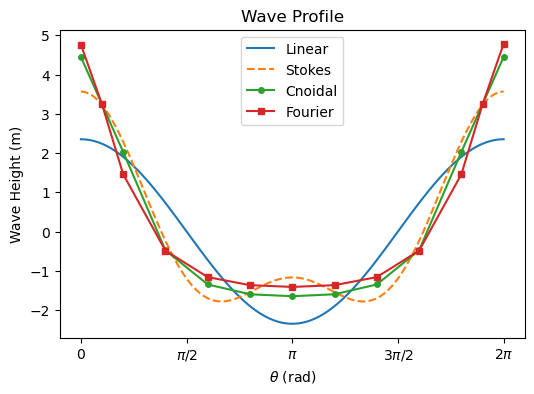

In [27]:
#Wave Profile Plot
plt.figure(figsize=(6,4))

linestyles = ['-', '--', None, None]
markers = [None, None, 'o', 's']
count = 0

for i, row in df.iterrows():
    plt.plot(row['theta'], row['wave_profile'], label=row.name, linestyle=linestyles[count], marker=markers[count], markersize = 4)
    count+=1

#plt.plot(theta, np.zeros(len(theta)))
plt.xlabel(r'$\theta$ (rad)')
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.ylabel('Wave Height (m)')
plt.title('Wave Profile')
plt.legend()
plt.savefig('Wave_Profile.jpg')
plt.show()

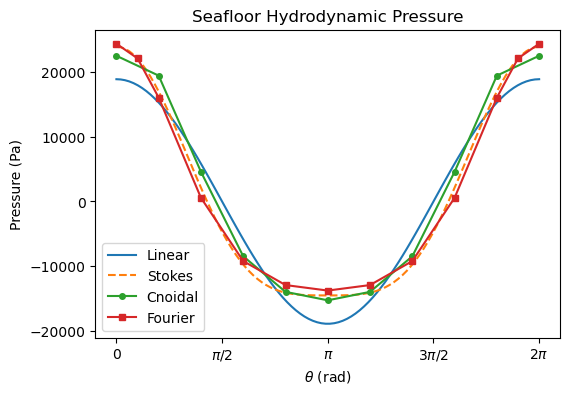

In [28]:
#Seafloor Hydrodynamic pressure
count = 0
plt.figure(figsize=(6,4))

for i, row in df.iterrows():
    plt.plot(row['theta'], row['seafloor_pressure'], label=row.name, linestyle=linestyles[count], marker=markers[count], markersize = 4)
    count+=1
plt.xlabel(r'$\theta$ (rad)')
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.ylabel('Pressure (Pa)')
plt.title('Seafloor Hydrodynamic Pressure')
plt.legend()
plt.savefig('Seafloor Pressure.jpg')
plt.show()

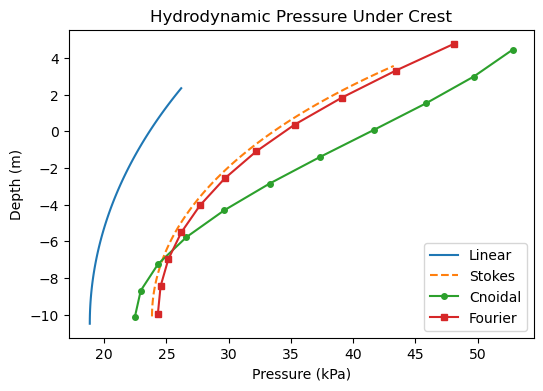

In [29]:
#Hydrodynamic pressure under crest
plt.figure(figsize=(6,4))
plt.plot(p_lin_cr/1000, z_cr, label='Linear', linestyle=linestyles[0], marker=markers[0], markersize=4) 
plt.plot(p_stokes_cr/1000, z_cr_s, label='Stokes', linestyle=linestyles[1], marker=markers[1], markersize=4)
plt.plot(p_under_crest_c/1000, depth_crest_c_raw, label='Cnoidal', linestyle=linestyles[2], marker=markers[2], markersize=4)
plt.plot(p_under_crest_f/1000, depth_crest_f_raw, label='Fourier', linestyle=linestyles[3], marker=markers[3], markersize=4)
plt.xlabel(r'Pressure (kPa)')
plt.ylabel('Depth (m)')
plt.title('Hydrodynamic Pressure Under Crest')
plt.legend()
plt.savefig('Crest Pressure.jpg')
plt.show()

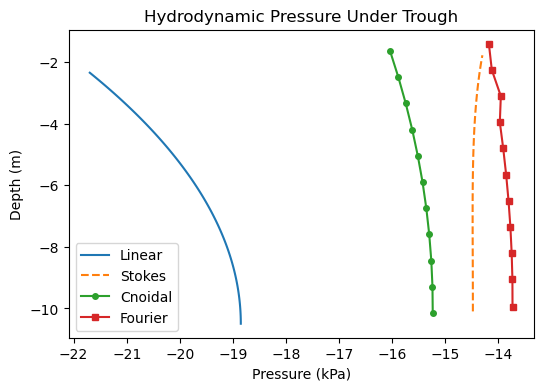

In [30]:
#Hydrodynamic pressure under Trough
plt.figure(figsize=(6,4))
plt.plot(p_lin_tr/1000, z_tr, label='Linear', linestyle=linestyles[0], marker=markers[0], markersize=4) 
plt.plot(p_stokes_tr/1000, z_tr_s, label='Stokes', linestyle=linestyles[1], marker=markers[1], markersize=4)
plt.plot(p_under_trough_c/1000, depth_trough_c_raw, label='Cnoidal', linestyle=linestyles[2], marker=markers[2], markersize=4)
plt.plot(p_under_trough_f/1000, depth_trough_f_raw, label='Fourier', linestyle=linestyles[3], marker=markers[3], markersize=4)
plt.xlabel(r'Pressure (kPa)')
plt.ylabel('Depth (m)')
plt.title('Hydrodynamic Pressure Under Trough')
plt.legend()
plt.savefig('Trough Pressure.jpg')
plt.show()

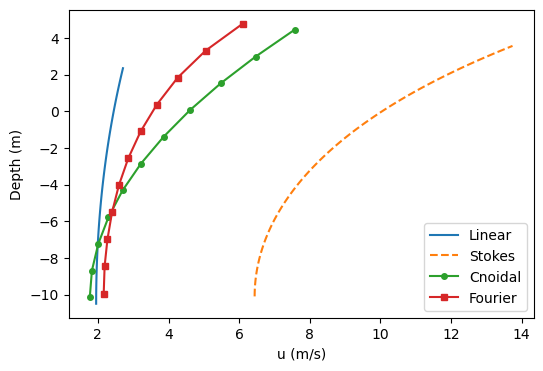

In [31]:
#u under crest
plt.figure(figsize=(6,4))
plt.plot(lin_u_cr, z_cr, label='Linear', linestyle=linestyles[0], marker=markers[0], markersize=4) 
plt.plot(stokes_u_cr, z_cr_s, label='Stokes', linestyle=linestyles[1], marker=markers[1], markersize=4)
plt.plot(u_under_crest_c_raw, depth_crest_c_raw, label='Cnoidal', linestyle=linestyles[2], marker=markers[2], markersize=4)
plt.plot(u_under_crest_f_raw, depth_crest_f_raw, label='Fourier', linestyle=linestyles[3], marker=markers[3], markersize=4)
plt.xlabel(r'u (m/s)')
plt.ylabel('Depth (m)')
plt.legend()
plt.savefig('crest velocity.jpg')
plt.show()

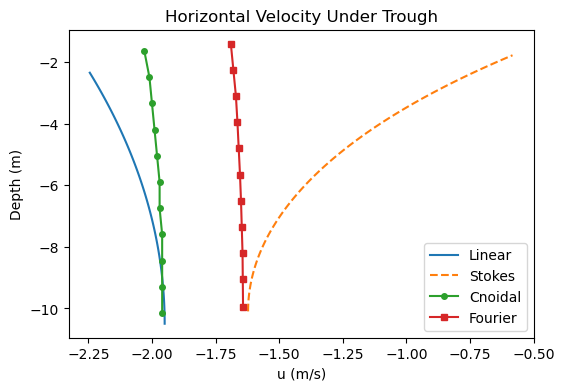

In [44]:
#u under trough
plt.figure(figsize=(6,4))
plt.plot(lin_u_tr, z_tr, label='Linear', linestyle=linestyles[0], marker=markers[0], markersize=4) 
plt.plot(stokes_u_tr, z_tr_s, label='Stokes', linestyle=linestyles[1], marker=markers[1], markersize=4)
plt.plot(u_under_trough_c_raw, depth_trough_c_raw, label='Cnoidal', linestyle=linestyles[2], marker=markers[2], markersize=4)
plt.plot(u_under_trough_f_raw, depth_trough_f_raw, label='Fourier', linestyle=linestyles[3], marker=markers[3], markersize=4)
plt.xlabel(r'u (m/s)')
plt.ylabel('Depth (m)')
plt.title('Horizontal Velocity Under Trough')
plt.legend()
plt.savefig('Trough Velocity.jpg')
plt.show()